## Imports

In [2]:
import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re
from scipy.spatial.transform import Rotation as R
import subprocess
from mpl_toolkits.mplot3d import Axes3D
import os
from scipy.interpolate import interp1d

## Defining the folder path 

In [ ]:
# folder_path = os.getcwd()
folder_path = "/Users/antoniamuhleck/Desktop/Hiwi/AWEWA/generating dust files"

## Reading CSV file

In [6]:
file_path_old =  os.path.join(folder_path, "AAA_3DOF_N8_d4_Nrings3_Ndup3_Nfar4_rectangle_convfar_double_new.csv")
file_path = os.path.join(folder_path, "outputs_megawes_trajectory_vlm_results.csv")
file_path_3dof = os.path.join(folder_path, "outputs_megawes_trajectory_vlm3DOF_results.csv")

df = pd.read_csv(file_path)
df_3dof = pd.read_csv(file_path_3dof)
df_old = pd.read_csv(file_path_old)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/antoniamuhleck/Desktop/Hiwi/AWEWA old stuff/generating dust files/outputs_megawes_trajectory_vlm_results.csv'

In [ ]:
df_old.head()

,x_q10_0,x_q10_1,x_q10_2,x_dq10_0,x_dq10_1,x_dq10_2,x_q21_0,x_q21_1,x_q21_2,x_dq21_0,...,theta_l_t_0,theta_t_f_0,nodes,parent,kites,cross_tether,converged,stats_t_wall_total,stats_t_wall_f_eval,stats_iterations
0,670.365939,7.285407,201.386298,-0.883810,0.000000,2.941946,1009.150644,-183.192637,406.176954,-10.233346,...,700.000007,4.821638,1.0,0.0,2.0,0,True,77.636972,40.087028,33.0
1,670.335618,7.281380,201.487320,-0.937698,-0.358292,3.132720,1008.827396,-186.688932,403.464990,-8.893268,...,NaN,NaN,2.0,1.0,3.0,0,True,77.636972,40.087028,33.0
2,670.303190,7.262994,201.595839,-0.986613,-0.744480,3.307417,1008.551341,-190.117498,400.656788,-7.464660,...,NaN,NaN,3.0,1.0,NaN,0,True,77.636972,40.087028,33.0
3,670.269013,7.230294,201.710635,-1.029396,-1.148631,3.461825,1008.325121,-193.472701,397.752758,-5.954337,...,NaN,NaN,NaN,NaN,NaN,0,True,77.636972,40.087028,33.0
4,670.233435,7.183435,201.830510,-1.065047,-1.561578,3.592299,1008.151211,-196.748929,394.753626,-4.368897,...,NaN,NaN,NaN,NaN,NaN,0,True,77.636972,40.087028,33.0


In [ ]:
df.head()

,x_q10_0,x_q10_1,x_q10_2,x_dq10_0,x_dq10_1,x_dq10_2,x_omega10_0,x_omega10_1,x_omega10_2,x_r10_0,...,outputs_xdot_from_var_dr10_7,outputs_xdot_from_var_dr10_8,time,theta_P_max_0,theta_diam_t_0,theta_t_f_0,nodes,parent,kites,cross_tether
0,286.222551,-152.807116,483.919779,2.742514,-47.998868,-16.778672,0.074464,0.046540,0.174480,0.215413,...,0.044165,-0.035561,0.000000,2500000.0,0.0297,27.003821,1.0,0.0,1.0,0
1,286.250347,-153.287492,483.751532,2.813167,-48.027692,-16.853143,0.074292,0.046301,0.174735,0.213793,...,0.044072,-0.035487,0.010005,NaN,NaN,NaN,NaN,NaN,NaN,0
2,286.278850,-153.768156,483.582538,2.884059,-48.056286,-16.927859,0.074121,0.046055,0.174992,0.212172,...,0.043974,-0.035416,0.020010,NaN,NaN,NaN,NaN,NaN,NaN,0
3,286.308063,-154.249105,483.412797,2.955191,-48.084645,-17.002820,0.073952,0.045801,0.175249,0.210551,...,0.043869,-0.035347,0.030015,NaN,NaN,NaN,NaN,NaN,NaN,0
4,286.337988,-154.730338,483.242305,3.026563,-48.112768,-17.078023,0.073785,0.045540,0.175507,0.208929,...,0.043758,-0.035280,0.040020,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
df_3dof.head()

,x_q10_0,x_q10_1,x_q10_2,x_dq10_0,x_dq10_1,x_dq10_2,x_coeff10_0,x_coeff10_1,x_l_t_0,x_dl_t_0,...,outputs_xdot_from_var_dq10_1,outputs_xdot_from_var_dq10_2,time,theta_P_max_0,theta_diam_t_0,theta_t_f_0,nodes,parent,kites,cross_tether
0,677.863499,269.835800,325.903859,39.095507,-32.343080,-54.540760,1.999999,-0.259426,799.076503,0.000000,...,-32.334045,-54.526532,0.000000,2500000.0,0.0297,39.999999,1.0,0.0,1.0,0
1,678.254813,269.510844,325.358351,39.149133,-32.632357,-54.532263,1.999999,-0.258904,799.076607,0.020859,...,-32.624714,-54.520228,0.010005,NaN,NaN,NaN,NaN,NaN,NaN,0
2,678.646675,269.182979,324.812915,39.201696,-32.922026,-54.522267,1.999999,-0.258382,799.076920,0.041718,...,-32.915672,-54.512262,0.020010,NaN,NaN,NaN,NaN,NaN,NaN,0
3,679.039073,268.852201,324.267566,39.253193,-33.212070,-54.510774,1.999999,-0.257859,799.077442,0.062577,...,-33.206904,-54.502640,0.030015,NaN,NaN,NaN,NaN,NaN,NaN,0
4,679.431996,268.518507,323.722322,39.303620,-33.502469,-54.497784,1.999999,-0.257337,799.078173,0.083436,...,-33.498396,-54.491371,0.040020,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
df_3dof["outputs_aerodynamics_ehat_chord1_0"]

0      -0.379568
1      -0.379536
2      -0.379491
3      -0.379434
4      -0.379364
          ...   
3994   -0.379289
3995   -0.379390
3996   -0.379470
3997   -0.379530
3998   -0.379568
Name: outputs_aerodynamics_ehat_chord1_0, Length: 3999, dtype: float64

In [ ]:
first_wing_trajectory = np.column_stack((df["x_q10_0"], df["x_q10_1"], df["x_q10_2"]))

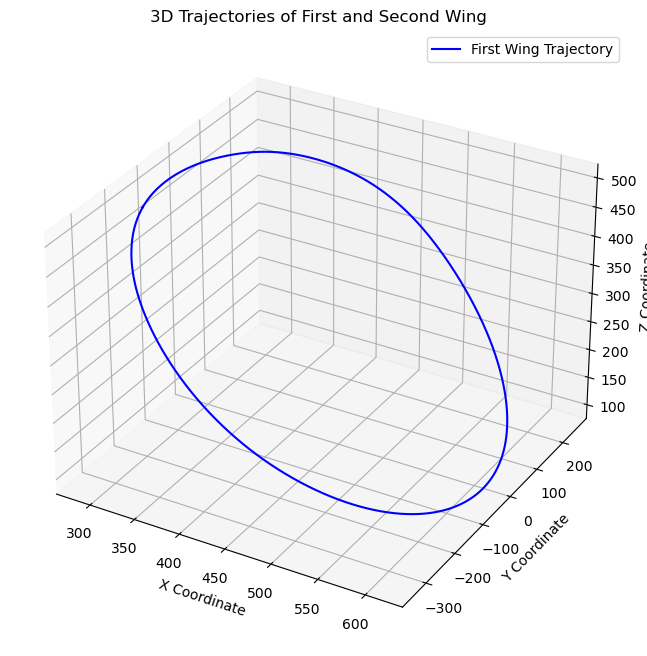

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot first wing trajectory
ax.plot(first_wing_trajectory[:, 0], 
    first_wing_trajectory[:, 1], 
    first_wing_trajectory[:, 2], 
    label="First Wing Trajectory", color="blue")


ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_zlabel("Z Coordinate")
ax.set_title("3D Trajectories of First and Second Wing")
ax.legend()

plt.show()

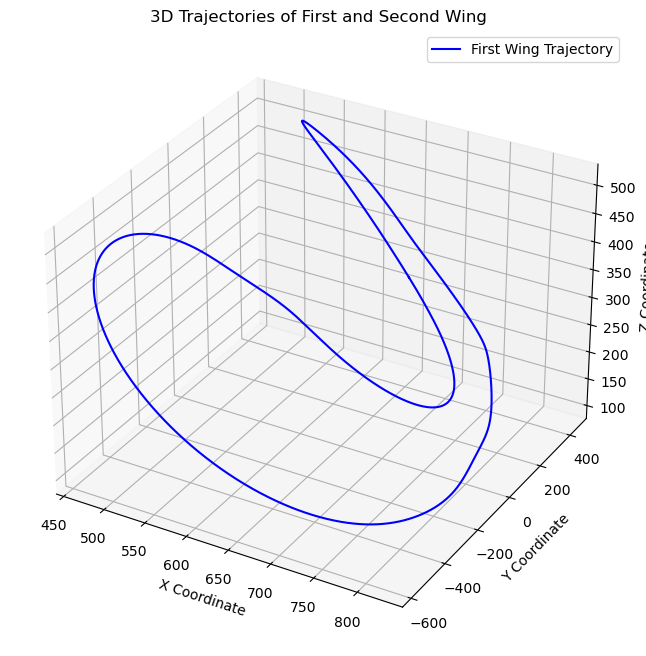

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot first wing trajectory
ax.plot(first_wing_trajectory[:, 0], 
    first_wing_trajectory[:, 1], 
    first_wing_trajectory[:, 2], 
    label="First Wing Trajectory", color="blue")


ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_zlabel("Z Coordinate")
ax.set_title("3D Trajectories of First and Second Wing")
ax.legend()

plt.show()

In [ ]:
def vector_rotation(e, v, theta):

    e_rot = e * np.cos(theta) + np.cross(v, e) * np.sin(theta) + v * np.dot(v, e) * (1 - np.cos(theta))

    return e_rot

def pitch_correction(R_vec, theta):

    R = np.array(R_vec).reshape(3, 3).T
    ex = R[:,0]
    ey = R[:,1]
    ez = R[:,2]

    ex_rot = vector_rotation(ex, ey, theta)
    ey_rot = vector_rotation(ey, ey, theta)
    ez_rot = vector_rotation(ez, ey, theta)

    R_rotated = np.vstack((
        ex_rot, ey_rot, ez_rot
    )).T.reshape(9,)

    return R_rotated

In [ ]:
def process_file(file_path, single_or_dual, apply_pitch_correction, CL0, alpha_max, alpha_min):

    """ Process the CSV file to extract all relevant data. 
        Applies pitch correction. This is neccesary to exactly match the 3D lift and drag curves of the wings used in awebox and DUST.
    Args:
        file_path (str): Path to the CSV file. 
        pitch_correction (bool): Whether to apply pitch correction.
        CL0 (float): Lift coefficient at zero angle of attack.(deduce from 3D drag curve)
        alpha_max (float): Maximum angle of attack in degrees.(deduce from 3D lift curve)
        alpha_min (float): Minimum angle of attack in degrees.(deduce from 3D lift curve)     
    Returns:
        tuple: A tuple containing:
            - u_inf (float): Average wind speed.
            - rho_inf (float): Average air density.
            - time (np.ndarray): Time array.
            - trajectories (list): List of np.ndarrays containing the trajectories of the wings.(just one for single, two for dual)
            - orientations (list): List of np.ndarrays containing the orientations of the wings.(just one for single, two for dual)
    """

    # Initialize lists to store data
    trajectories = []
    orientations = []
    ll_u_inf = []
    ll_rho_inf = []

    # Read the CSV file and extract time column
    df = pd.read_csv(file_path)
    time = df["time"].to_numpy()

    # Determine indices based on single or dual wing configuration
    if single_or_dual == "single":
        ll_indices = [1]
        node = 0
    elif single_or_dual == "dual":
        ll_indices = [2, 3]
        node = 1

    # Loop through each wing index to extract relevant data
    for i in ll_indices:
        ll_u_inf.append(df[f"outputs_aerodynamics_u_infty{i}_0"])
        ll_rho_inf.append(df[f"outputs_aerodynamics_air_density{i}_0"])
        trajectories.append(np.column_stack((df[f"x_q{i}{node}_0"], df[f"x_q{i}{node}_1"], df[f"x_q{i}{node}_2"])))

        orientation = (np.column_stack((
            df[f"outputs_aerodynamics_ehat_chord{i}_0"],
            df[f"outputs_aerodynamics_ehat_chord{i}_1"],
            df[f"outputs_aerodynamics_ehat_chord{i}_2"],
            df[f"outputs_aerodynamics_ehat_span{i}_0"],
            df[f"outputs_aerodynamics_ehat_span{i}_1"],
            df[f"outputs_aerodynamics_ehat_span{i}_2"],
            df[f"outputs_aerodynamics_ehat_up{i}_0"],
            df[f"outputs_aerodynamics_ehat_up{i}_1"],
            df[f"outputs_aerodynamics_ehat_up{i}_2"])))
        
        if apply_pitch_correction == False:
            orientations.append(orientation)
        
        elif apply_pitch_correction == True:
            lift_coefficient = df[f'x_coeff{i}{node}_0']
            CL_pr = 1 / (np.deg2rad(alpha_max - alpha_min))
            alpha = [(lift_coefficient[k] - CL0) / CL_pr for k in range(len(lift_coefficient))]
    
            orientation_corrected = np.array([
                pitch_correction(orientation[k, :], alpha[k]) for k in range(len(alpha))
            ])
            
            orientations.append(orientation_corrected)

    u_inf = np.mean(ll_u_inf)
    rho_inf = np.mean(ll_rho_inf)

    return u_inf, rho_inf, time, trajectories, orientations

In [ ]:
u_inf, rho_inf, time, trajectories, orientations = process_file(file_path_3dof,"single", True, 0, 12, 0)

## Calculating euler angles

In [ ]:
def compute_euler_angles(orientation):

    R_matrix = np.array(orientation).reshape(3, 3)
    euler_angles = R.from_matrix(R_matrix).as_euler('ZXZ')

    return tuple(euler_angles)


## Concatenating data for several rotations

In [ ]:
def concatenate_time(n,time_list):

    concatenated_time_list = time_list

    if n == 1:
        return concatenated_time_list
    else:
        for i in range(1,n):
            concatenated_time_list = np.concatenate((concatenated_time_list, time_list[1:] + i * time_list[-1]), axis=0)

        return concatenated_time_list

In [ ]:
def concatenate_data_periodic(n, data):

    concatenated_data = data
    if n == 1:
        return concatenated_data
    else:
        for i in range(1,n):
            concatenated_data = np.concatenate((concatenated_data, data[1:]), axis=0)

        return np.array(concatenated_data)

In [ ]:
def concatenate_data_semiperiodic(n, data_1, data_2):

    result = []
    result.extend(data_1)
    for i in range(1,n):
        if i % 2 == 0:
            result.extend(data_1[1:])
        else:
            result.extend(data_2[1:])

    return np.array(result)

In [ ]:
def create_trajectory_and_orientation_files(single_or_dual, n_rot, res, file_path, folder_path, apply_pitch_correction, CL0, alpha_max, alpha_min):
    """
    Create trajectory and orientation files for multiple rotations. Computes Euler angles from orientation matrices and saves the data to .dat files.

    Args:
        single_or_dual (str): "single" for single wing, "dual" for dual wing configuration.
        n_rot (int): Number of rotations.
        res (int): Resolution for the data. If res=1, all data is used; if res=2, every second data point is used...
                   This is useful to reduce the time of the simulation.
        file_path (str): Path to the CSV file containing the data.
        folder_path (str): Path to the output directory where the .dat files will be saved.
        apply_pitch_correction (bool): Whether to apply pitch correction.
        CL0 (float): Lift coefficient at zero angle of attack.(deduce from 3D drag curve)
        alpha_max (float): Maximum angle of attack in degrees.(deduce from 3D lift curve)
        alpha_min (float): Minimum angle of attack in degrees.(deduce from 3D lift curve)
     
    Returns:
        saves the data to .dat files and returns the time, and lists containing the trajectories and Euler angles of the wing(s).
    """

    u_inf, rho_inf, time, trajectories, orientations = process_file(file_path, single_or_dual, apply_pitch_correction, CL0, alpha_max, alpha_min) 
    
    trajectories_mult_rot = []
    time_mult_rot = concatenate_time(n_rot, time)[::res]

    # Compute Euler angles and concatenate data based on single or dual wing configuration
    if single_or_dual == "single":

        ll_names = ["first_wing"]
        trajectories_mult_rot.append(concatenate_data_periodic(n_rot, trajectories[0])[::res])

        euler_angles = [compute_euler_angles(orientation) for orientation in orientations[0]]

        euler_angles_mult_rot = concatenate_data_periodic(n_rot,euler_angles)[::res]
        euler_angles_mult_rot = [np.column_stack([np.unwrap(euler_angles_mult_rot[:, i]) for i in range(3)])]

    elif single_or_dual == "dual":  

        ll_names = ["first_wing", "second_wing"]
        trajectories_mult_rot = [concatenate_data_semiperiodic(n_rot, trajectories[0], trajectories[1])[::res], concatenate_data_semiperiodic(n_rot, trajectories[1], trajectories[0])[::res]]

        first_wing_euler_angles = [compute_euler_angles(orientation) for orientation in orientations[0]]
        second_wing_euler_angles = [compute_euler_angles(orientation) for orientation in orientations[1]]

        first_wing_euler_angles_mult_rot = (concatenate_data_semiperiodic(n_rot, first_wing_euler_angles, second_wing_euler_angles)[::res])
        second_wing_euler_angles_mult_rot = (concatenate_data_semiperiodic(n_rot, second_wing_euler_angles, first_wing_euler_angles)[::res])

        first_wing_euler_angles_mult_rot = np.column_stack([np.unwrap(first_wing_euler_angles_mult_rot[:, i]) for i in range(3)])
        second_wing_euler_angles_mult_rot = np.column_stack([np.unwrap(second_wing_euler_angles_mult_rot[:, i]) for i in range(3)])  

        euler_angles_mult_rot = [first_wing_euler_angles_mult_rot, second_wing_euler_angles_mult_rot]

    for i, name in enumerate(ll_names):
        # save trajectory data in .dat file with time in the specified folder
        trajectory_data = np.column_stack((time_mult_rot, np.array(trajectories_mult_rot[i])))
        np.savetxt(f"{folder_path}/{name}_trajectory.dat", trajectory_data, delimiter="\t", fmt="%.8f")

        for name, angles in zip(ll_names, euler_angles_mult_rot):
            for angle_name, i in zip(["Z1", "X", "Z2"], range(3)):
                np.savetxt(f"{folder_path}/{name}_euler_angle_{angle_name}.dat", np.column_stack((time_mult_rot, np.unwrap(np.array(angles)[:, i]))), delimiter="\t", fmt="%.8f")


    return time_mult_rot, trajectories_mult_rot, euler_angles_mult_rot


In [ ]:
time_mult_rot, trajectories_mult_rot, euler_angles_mult_rot = create_trajectory_and_orientation_files("single", 4, res, file_path, folder_path, apply_pitch_correction = False, CL0=0, alpha_max=12, alpha_min=0)

## Visualizing trajectories and euler angles 

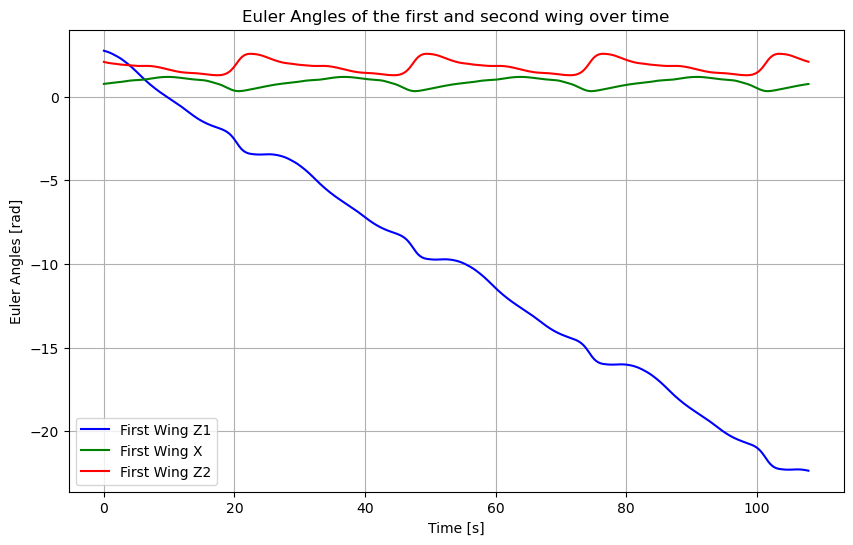

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(time_mult_rot, euler_angles_mult_rot[0][:,0], label="First Wing Z1", color="blue")
# plt.plot(time_mult_rot, euler_angles_mult_rot[1][:,0], label="Second Wing Z1", color="blue", linestyle="--")

plt.plot(time_mult_rot, euler_angles_mult_rot[0][:,1], label="First Wing X", color="green")
# plt.plot(time_mult_rot, euler_angles_mult_rot[1][:,1], label="Second Wing X", color="green", linestyle="--")

plt.plot(time_mult_rot, euler_angles_mult_rot[0][:,2], label="First Wing Z2", color="red")
# plt.plot(time_mult_rot, euler_angles_mult_rot[1][:,2], label="Second Wing Z2", color="red", linestyle="--")

plt.xlabel("Time [s]")
plt.ylabel("Euler Angles [rad]")
plt.title("Euler Angles of the first and second wing over time")
plt.legend()
plt.grid()
plt.show()

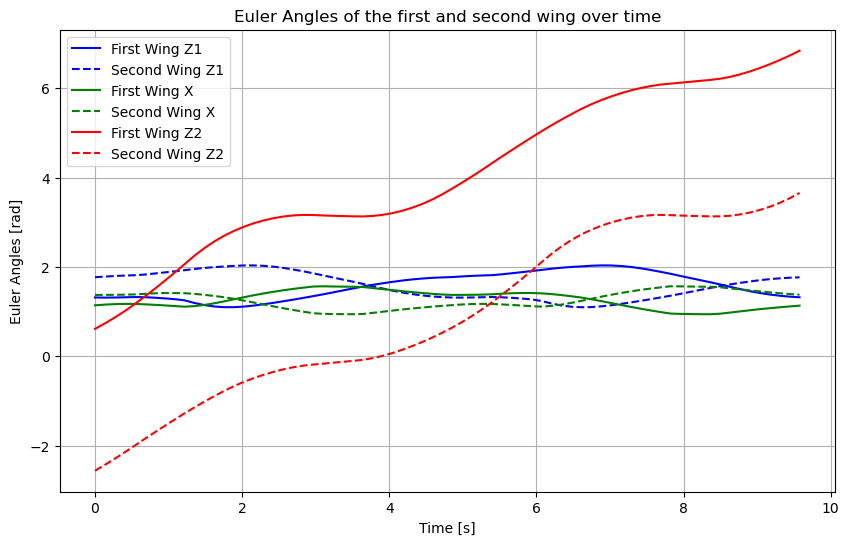

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(time_mult_rot, euler_angles_mult_rot[0][:,0], label="First Wing Z1", color="blue")
plt.plot(time_mult_rot, euler_angles_mult_rot[1][:,0], label="Second Wing Z1", color="blue", linestyle="--")

plt.plot(time_mult_rot, euler_angles_mult_rot[0][:,1], label="First Wing X", color="green")
plt.plot(time_mult_rot, euler_angles_mult_rot[1][:,1], label="Second Wing X", color="green", linestyle="--")

plt.plot(time_mult_rot, euler_angles_mult_rot[0][:,2], label="First Wing Z2", color="red")
plt.plot(time_mult_rot, euler_angles_mult_rot[1][:,2], label="Second Wing Z2", color="red", linestyle="--")

plt.xlabel("Time [s]")
plt.ylabel("Euler Angles [rad]")
plt.title("Euler Angles of the first and second wing over time")
plt.legend()
plt.grid()
plt.show()

## Writing and modifying dust files

### Writing the geometry input file for an elliptic wing (ParamWing.in)

In [368]:
def height_of_an_ellipse(A,a):
    """
    Calculate the height of an ellipse given the semi-major axis A and semi-minor axis a.
    
    Args:
        A (float): Area of the ellipse
        a (float): Half of the semi-major axis of the ellipse.
    
    Returns:
        float: Half of the semi-minoe axis of the ellipse.
    """
    return 2*A/(np.pi*a)

In [369]:
def create_elliptic_wing(folder_path, AR, span, N_elements, nelem_span, airfoil_profile, end_chord):
    """
    Create an elliptic wing definition file for DUST.
    
    Args:
        folder_path (str): Path to the folder where the ParamWing.in file will be created.
        AR (float): Aspect ratio of the wing.
        span (float): Span of the wing.
        N_elements (int): Number of elements in the span direction.
        nelem_span (int): Number of elements in the span direction.
        airfoil_profile (str): Airfoil profile to be used for the wing sections, can be one of the NACA 4 digit airfoils, e.g. "NACA0012" or "NACA4412".
        end_chord (float): Chord length at the wing tip.

    Returns:
        None: Creates or updates the ParamWing.in file in the specified folder with the wing definition if the content is different.
    """

    file_path = f"{folder_path}/ParamWing.in"

    # Calculate the center chord of the elliptic wing
    A = span**2 / AR
    center_chord = height_of_an_ellipse(A, span / 2)

    # Calculate the chord length sections for the elliptic wing
    ll_chord_sections = []
    for n in range(0, int(N_elements / 2)):
        x = span / N_elements * n
        y = center_chord / 2 * np.sqrt(1 - x**2 / (span / 2)**2)
        ll_chord_sections.append(np.round(2 * y, 5))

    # Generate the new content for the file
    first_block = f"""mesh_file_type = parametric
el_type = l

mesh_symmetry = T
symmetry_point = (/0.0 ,0.0, 0.0/)
symmetry_normal = (/0.0 , 1.0, 0.0/)

starting_point = (/0.0,0.0,0.0/)
! reference_chord_fraction = 0.5

type_chord = uniform
"""

    sections_and_regions = ""
    for i, y in enumerate(ll_chord_sections, start=1):
        sections_and_regions += f"""
! section {i}
chord = {y}
twist = 0.0 ! deg
airfoil_table = ./airfoils/naca0012.c81
airfoil = {airfoil_profile}

! region {i}
span = {np.round(span / N_elements, 5)}
sweep = 0.0 ! deg
dihed = 0.0 ! deg
nelem_span = {nelem_span}
type_span = uniform
"""

    sections_and_regions += f"""
! section {N_elements / 2 + 1}
chord = {end_chord}
twist = 0.0 ! deg
airfoil_table = ./airfoils/naca0012.c81
airfoil = {airfoil_profile}
"""

    new_content = first_block + sections_and_regions

    # Check if the file exists and compare the content
    if os.path.exists(file_path):
        with open(file_path, 'r') as file:
            existing_content = file.read()

        # Update the file only if the content is different
        if existing_content != new_content:
            with open(file_path, 'w') as file:
                file.write(new_content)
    else:
        # Create the file and write the new content
        with open(file_path, 'w') as file:
            file.write(new_content)


In [370]:
AR = 10
span = 44.7
N_elements = 20
nelem_span = 5
airfoil_profile = "NACA0012"

create_elliptic_wing(folder_path, AR, span, N_elements, nelem_span, airfoil_profile, end_chord=1.0)

### Writing the preprocessor input file (dust_pre.in)

In [371]:
def create_or_change_dust_pre_in(folder_path, single_or_dual):
    """
    Creates or modifies the dust_pre.in file in the specified folder.
    
    Args:
        folder_path (str): Path to the folder where the dust_pre.in file will be created or modified.
        single_or_dual (str): Specifies whether to create a single or dual system.

    Returns:
        None: Creates or modifies the dust_pre.in file in the specified folder.
    """
    file_path = f"{folder_path}/dust_pre.in"

    if single_or_dual == "single":
        content = """

comp_name = first_wing
geo_file = ParamWing.in
ref_tag = first_wing

file_name = geo_input.h5 
        """
    elif single_or_dual == "dual":
        content = """
comp_name = first_wing
geo_file = ParamWing.in
ref_tag = first_wing

comp_name = second_wing
geo_file = ParamWing.in
ref_tag = second_wing

file_name = geo_input.h5 
        """
    # Check if the file exists and compare the content
    if os.path.exists(file_path):
        with open(file_path, 'r') as file:
            existing_content = file.read()

        # Update the file only if the content is different
        if existing_content != content:
            with open(file_path, 'w') as file:
                file.write(content)
    else:
        # Create the file and write the new content
        with open(file_path, 'w') as file:
            file.write(content)

### Writing the references input file (References.in)

In [372]:
def create_reference_system(ref_tags_lst, files_lst, origin): 

    content = f"""
reference_tag = {ref_tags_lst[0]}
parent_tag = 0
origin = {origin}
orientation = (/1.0,0.0,0.0, 0.0,1.0,0.0, 0.0,0.0,1.0/)
multiple = F 
moving = T
motion = {{
pole = {{
input = position
input_type = from_file
file = {files_lst[0]}
}}
rotation = {{
input = position
input_type = simple_function
function = 0
Axis = (/ 1.0 , 0.0 , 0.0 /)
amplitude = 0.0
}}
}} 

reference_tag = {ref_tags_lst[1]}
parent_tag = {ref_tags_lst[0]} ! 0 : absolute reference frame
origin = (/0.,0.,0./)
orientation = (/1.0,0.0,0.0, 0.0,1.0,0.0, 0.0,0.0,1.0/)
multiple = F 
moving = T
motion = {{
pole = {{
input = position
input_type = simple_function
function = (/ 0 , 0 , 0 /)
amplitude = 0.00
}}
rotation = {{
input = position
input_type = from_file
file = {files_lst[1]}
Axis = (/ 0.0 , 0.0 , 1.0 /)
}}
}} 

reference_tag = {ref_tags_lst[2]}
parent_tag = {ref_tags_lst[1]} ! 0 : absolute reference frame! 
origin = (/0.,0.,0./)
orientation = (/1.0,0.0,0.0, 0.0,1.0,0.0, 0.0,0.0,1.0/)
multiple = F 
moving = T
motion = {{
pole = {{
input = position
input_type = simple_function
function = (/ 0 , 0 , 0 /)
amplitude = 0.00
}}
rotation = {{
input = position
input_type = from_file
file = {files_lst[2]}
Axis = (/ 1.0 , 0.0 , 0.0 /)
}}
}} 

reference_tag = {ref_tags_lst[3]}
parent_tag = {ref_tags_lst[2]} ! 0 : absolute reference frame
origin = (/0.,0.,0./)
orientation = (/1.0,0.0,0.0, 0.0,1.0,0.0, 0.0,0.0,1.0/)
multiple = F 
moving = T
motion = {{
pole = {{
input = position
input_type = simple_function
function = (/ 0 , 0 , 0 /)
amplitude = 0.00
}}
rotation = {{
input = position
input_type = from_file
file = {files_lst[3]}
Axis = (/ 0.0 , 0.0 , 1.0 /)
}}
}} 

reference_tag = {ref_tags_lst[4]}
parent_tag = {ref_tags_lst[3]} ! 0 : absolute reference frame
origin = (/0.,0.,0./)
orientation = (/1.0,0.0,0.0, 0.0,1.0,0.0, 0.0,0.0,1.0/)
multiple = F 
moving = F
"""
    
    return content

In [373]:
def create_or_change_references_in(folder_path, single_or_dual, origins): 
    
    file_path = f"{folder_path}/References.in"

    ref_tags_first_wing = ["first_trajectory", "first_wing_euler_angle_Z1", "first_wing_euler_angle_X", "first_wing_euler_angle_Z2", "first_wing"]
    ref_tags_second_wing = ["second_trajectory", "second_wing_euler_angle_Z1", "second_wing_euler_angle_X", "second_wing_euler_angle_Z2", "second_wing"]

    files_first_wing = [ "first_wing_trajectory.dat", "first_wing_euler_angle_Z1.dat", "first_wing_euler_angle_X.dat", "first_wing_euler_angle_Z2.dat" ]
    files_second_wing = [ "second_wing_trajectory.dat", "second_wing_euler_angle_Z1.dat", "second_wing_euler_angle_X.dat", "second_wing_euler_angle_Z2.dat"]

    if single_or_dual == "single":
        content = create_reference_system(ref_tags_first_wing, files_first_wing, origins[0])

    elif single_or_dual == "dual":

        content_first = create_reference_system(ref_tags_first_wing, files_first_wing, origins[0])
        content_second = create_reference_system(ref_tags_second_wing, files_second_wing, origins[1])
        content = content_first + "\n" + content_second

    # Check if the file exists and compare the content
    if os.path.exists(file_path):
        with open(file_path, 'r') as file:
            existing_content = file.read()

        # Update the file only if the content is different
        if existing_content != content:
            with open(file_path, 'w') as file:
                file.write(content)
    else:
        # Create the file and write the new content
        with open(file_path, 'w') as file:
            file.write(content)


### Writing the solver input file (dust.in)

In [374]:
ceil_to_nearest = lambda x, d: int(np.ceil(x / d)) * d

def calculate_octree_parameters(file_path, t_end, d):

    df = pd.read_csv(file_path)

    u_inf_max  = np.max(df["outputs_aerodynamics_u_infty2_0"])

    x_max = ceil_to_nearest(max(df["x_q21_0"].max(), df["x_q31_0"].max()) + d + t_end * u_inf_max, d)
    x_min = ceil_to_nearest(min(df["x_q21_0"].min(), df["x_q31_0"].min()) - d, d)

    y_max = ceil_to_nearest(max(df["x_q21_1"].max(), df["x_q31_1"].max()) + 4*d, d)
    y_min = ceil_to_nearest(min(df["x_q21_1"].min(), df["x_q31_1"].min()) - 5*d, d)

    z_max = ceil_to_nearest(max(df["x_q21_2"].max(), df["x_q31_2"].max()) + 4*d, d)
    z_min = ceil_to_nearest(min(df["x_q21_2"].min(), df["x_q31_2"].min()) - 4*d, d)

    dx = int((x_max - x_min)/d)
    dy = int((y_max - y_min)/d)
    dz = int((z_max - z_min)/d)

    min_xyz = f"(/{x_min}, {y_min}, {z_min}/)"
    max_xyz = f"(/{x_max}, {y_max}, {z_max}/)"
    n_box = f"(/{dx}, {dy}, {dz}/)"

    return (min_xyz, max_xyz, n_box)

In [375]:
def create_or_change_dust_in(folder_path, t_start, t_end, dt, u_inf, particles_box_min, particles_box_max, n_box, box_length, rho_inf): 

    file_path = f"{folder_path}/dust.in"

    new_content = f"""

basename       = ./Output/flapwing

! --- Time parameters ---
tstart = {t_start}
tend = {t_end}
dt = {dt}
dt_out = {dt}
output_start = T
! ndt_update_wake = 1

! --- Restart ---
restart_from_file = F

! --- Geometry files ---
geometry_file = geo_input.h5
reference_file = References.in

! --- stream parameters ---
u_inf = (/ {u_inf}, 0.0, 0.0 /)

! wake parameters  -------------
n_wake_panels = 2
n_wake_particles = 20000000

! wake regularisation ------------
divergence_filtering = T
filter_time_scale = 20
doublet_threshold = 0.01
rankine_rad = 0.12
vortex_rad = 0.12
cutoff_rad = 0.01

! Model parameters -------------------
particles_box_min = {particles_box_min}
particles_box_max = {particles_box_max}
fmm = T

! octree parameters--------------------
box_length = {box_length}
n_box = {n_box} ! number of octree boxes in each direction, e.g. (20, 20, 20)
octree_origin = {particles_box_min}
n_octree_levels = 4 ! subdivision of octree cubes, reduce to make faster
min_octree_part = 5 ! if a subdivision contains less particles that that, dust stops further divisions
multipole_degree = 2 
vortstretch = T
diffusion = T


! --- Lifting Lines parameters ---
ll_solver = GammaMethod
ll_reynolds_corrections = F
ll_max_iter = 100
ll_tol = 1.0e-4
ll_damp = 20
ll_loads_avl = F 

"""

    # Check if the file exists and compare the content
    if os.path.exists(file_path):
        with open(file_path, 'r') as file:
            existing_content = file.read()

        # Update the file only if the content is different
        if existing_content != new_content:
            with open(file_path, 'w') as file:
                file.write(new_content)
    else:
        # Create the file and write the new content
        with open(file_path, 'w') as file:
            file.write(new_content)

In [376]:
def create_or_change_dust_in_panels(folder_path, t_start, t_end, dt, u_inf, rho_inf): 

    file_path = f"{folder_path}/dust.in"

    n_wake_panels = int(((float(t_end) - float(t_start)) / float(dt)) * 1.2)

    new_content = f"""

    
basename       = ./Output/flapwing

! --- Time parameters ---
tstart = {t_start}
tend = {t_end}
dt = {dt}
dt_out = {dt}
output_start = T
! ndt_update_wake = 1

! --- Restart ---
restart_from_file = F

! --- Geometry files ---
geometry_file = geo_input.h5
reference_file = References.in

! --- stream parameters ---
u_inf = (/ {u_inf}, 0.0, 0.0 /)
rho_inf = {rho_inf}

! wake parameters -------------
n_wake_panels = {n_wake_panels}

! Model parameters -------------------
fmm = F
vortstretch = F
diffusion = F

"""

    # Check if the file exists and compare the content
    if os.path.exists(file_path):
        with open(file_path, 'r') as file:
            existing_content = file.read()

        # Update the file only if the content is different
        if existing_content != new_content:
            with open(file_path, 'w') as file:
                file.write(new_content)
    else:
        # Create the file and write the new content
        with open(file_path, 'w') as file:
            file.write(new_content)

### Writing the postprocessor input file (dust_post.in)

#### Load analysis

In [377]:
def average_time_step(lst):
    return np.average(np.diff(lst))

In [378]:
def create_or_change_load_analysis_single(folder_path, start_res, end_res, step_res, name, component, ref_tag):
    """
    Removes the current visualization block if it exists and adds the new one.
    If no wake visualization block exists, it simply adds the new one.

    Args:
        folder_path (str): Path to the folder where the dust_post.in file is located.
        start_res (int): The simulation step at which you want to start the flow field analysis.
        end_res (int): The simulation step at which you want to end the flow field analysis.

    Returns:
        None: Creates or modifies the wake visualization block in the dust_post.in file.
    """

    file_path = f"{folder_path}/dust_post.in"
    loads_block = f"""analysis = {{

type = integral_loads
name = {name}
start_res = {start_res}
end_res = {end_res}
step_res  = {step_res}
format   = dat

component = {component} 
reference_tag = {ref_tag}

}}
"""

    # Read the file content
    with open(file_path, 'r') as file:
        content = file.read()

    # Remove any existing flow_field analysis block
    analysis_start = content.find("analysis = {")
    while analysis_start != -1:
        analysis_end = content.find("}", analysis_start) + 1
        existing_block = content[analysis_start:analysis_end]
        if f"type = integral_loads" in existing_block:
            content = content.replace(existing_block, "")
        analysis_start = content.find("analysis = {", analysis_start + 1)

    # Add the new flow_field analysis block
    content += "\n" + loads_block
    # Write the updated content back to the file
    with open(file_path, 'w') as file:
        file.write(content)

In [379]:
def create_or_change_load_analysis_dual(folder_path, start_res, end_res, step_res, names, components, ref_tags):
    """
    Removes the current visualization block if it exists and adds the new one.
    If no wake visualization block exists, it simply adds the new one.

    Args:
        folder_path (str): Path to the folder where the dust_post.in file is located.
        start_res (int): The simulation step at which you want to start the flow field analysis.
        end_res (int): The simulation step at which you want to end the flow field analysis.

    Returns:
        None: Creates or modifies the wake visualization block in the dust_post.in file.
    """

    file_path = f"{folder_path}/dust_post.in"
    loads_block = f"""analysis = {{

type = integral_loads
name = {names[0]}
start_res = {start_res}
end_res = {end_res}
step_res  = {step_res}
format   = dat

component = {components[0]} 
reference_tag = {ref_tags[0]}
    }}
analysis = {{

type = integral_loads
name = {names[1]}
start_res = {start_res}
end_res = {end_res}
step_res  = {step_res}
format   = dat

component = {components[1]} 
reference_tag = {ref_tags[1]}

}}
"""

    # Read the file content
    with open(file_path, 'r') as file:
        content = file.read()

    # Remove any existing flow_field analysis block
    analysis_start = content.find("analysis = {")
    while analysis_start != -1:
        analysis_end = content.find("}", analysis_start) + 1
        existing_block = content[analysis_start:analysis_end]
        if f"type = integral_loads" in existing_block:
            content = content.replace(existing_block, "")
        analysis_start = content.find("analysis = {", analysis_start + 1)

    # Add the new flow_field analysis block
    content += "\n" + loads_block
    # Write the updated content back to the file
    with open(file_path, 'w') as file:
        file.write(content)

#### Visualization

In [380]:
def create_or_change_wake_visualization(folder_path, start_res, end_res, step_res):
    """
    Removes the current visualization block if it exists and adds the new one.
    If no wake visualization block exists, it simply adds the new one.

    Args:
        folder_path (str): Path to the folder where the dust_post.in file is located.
        start_res (int): The simulation step at which you want to start the flow field analysis.
        end_res (int): The simulation step at which you want to end the flow field analysis.

    Returns:
        None: Creates or modifies the wake visualization block in the dust_post.in file.
    """

    file_path = f"{folder_path}/dust_post.in"
    wake_vis_block = f"""analysis = {{
  name = v1
  type = Viz

  format = vtk

  start_res = {start_res}
  end_res = {end_res}
  step_res = {step_res}
  wake = T

  variable = Vorticity

}}
"""

    # Read the file content
    with open(file_path, 'r') as file:
        content = file.read()

    # Remove any existing flow_field analysis block
    analysis_start = content.find("analysis = {")
    while analysis_start != -1:
        analysis_end = content.find("}", analysis_start) + 1
        existing_block = content[analysis_start:analysis_end]
        if f"type = Viz" in existing_block:
            content = content.replace(existing_block, "")
        analysis_start = content.find("analysis = {", analysis_start + 1)

    # Add the new flow_field analysis block
    content += "\n" + wake_vis_block

    # Write the updated content back to the file
    with open(file_path, 'w') as file:
        file.write(content)

#### Flowfield analysis

In [549]:
def calculate_flowfield_parameters_xy_single(file_path):
    """
    Calculate flowfield parameters for a single kite system:
    - min and max coordinates of evaluation points
    - v_normal vector along tether direction

    Args:
        file_path (str): Path to the CSV file containing the data.

    Returns:
        tuple: A tuple containing:
            - min_xyz (str): Minimum coordinates in the format "(x_min, y_min, z_min)".
            - max_xyz (str): Maximum coordinates in the format "(x_max, y_max, z_max)".
            - v_normal (np.ndarray): Normalized vector representing the elevation angle.
    """
    plot_dict = pd.read_csv(file_path)

    # Calculate elevation angle
    elevation_opt = np.arcsin(np.mean(plot_dict['x_q10_2']) / plot_dict["x_l_t_0"][0])
    v_normal = [np.cos(elevation_opt), 0, np.sin(elevation_opt)]

    # Rotation matrix around y-axis
    Roty = np.array([[np.cos(elevation_opt), 0, np.sin(elevation_opt)], 
                     [0, 1, 0], 
                     [-np.sin(elevation_opt), 0, np.cos(elevation_opt)]])

    # --- Single kite: only use q21 (instead of averaging q21 & q31) ---
    eval_e1 = np.mean(plot_dict['x_q10_0'])
    eval_e3 = np.mean(plot_dict['x_q10_2'])
    eval_rot = np.dot(Roty, np.array([[eval_e1], [0], [eval_e3]])).squeeze()

    # Define evaluation grid in local frame
    lims = [[-800, 800], [-800, 800]]
    resolution = 3
    evaluation_points_e1 = np.linspace(lims[0][0], lims[0][1], resolution)
    evaluation_points_e2 = np.linspace(lims[1][0], lims[1][1], resolution)

    # Transform back to global coordinates
    pstns = []
    for ep_e1 in evaluation_points_e1:
        for ep_e2 in evaluation_points_e2:
            p_k = np.dot(Roty.T, np.array([[eval_rot[0]], [ep_e1], [ep_e2]]))
            pstns.append(p_k)

    pstns = np.array(pstns)
    x_max, x_min = np.round(np.max(pstns[:, 0]), 1), np.round(np.min(pstns[:, 0]), 1)
    y_max, y_min = np.round(np.max(pstns[:, 1]), 1), np.round(np.min(pstns[:, 1]), 1)
    z_max, z_min = np.round(np.max(pstns[:, 2]), 1), np.round(np.min(pstns[:, 2]), 1)

    min_xyz = f"(/{x_min}, {y_min}, {z_min}/)"
    max_xyz = f"(/{x_max}, {y_max}, {z_max}/)"

    return min_xyz, max_xyz, np.round(v_normal, 3)


In [ ]:
def calculate_flowfield_parameters_xy(file_path):
    """
    Calculate flowfield parameters including v_normal, x_max, x_min, y_max, y_min, z_max, and z_min.

    Args:
        file_path (str): Path to the CSV file containing the data.

    Returns:
        tuple: A tuple containing:
            - min_xyz (str): Minimum coordinates in the format "(x_min, y_min, z_min)".
            - max_xyz (str): Maximum coordinates in the format "(x_max, y_max, z_max)".
            - v_normal (np.ndarray): Normalized vector representing the elevation angle. (needed to calculate the component of the velocity/force that acts along the tether direction)

    """
    plot_dict = pd.read_csv(file_path)

    elevation_opt = np.arcsin(np.mean(plot_dict['x_q10_2']) / plot_dict['theta_l_t_0'][0])
    v_normal = [np.cos(elevation_opt), 0, np.sin(elevation_opt)]
    Roty = np.array([[np.cos(elevation_opt), 0, np.sin(elevation_opt)], 
                     [0, 1, 0], 
                     [-np.sin(elevation_opt), 0, np.cos(elevation_opt)]])

    eval_e1 = 0.5 * np.mean(plot_dict['x_q21_0']) + 0.5 * np.mean(plot_dict['x_q31_0'])
    eval_e3 = 0.5 * np.mean(plot_dict['x_q21_2']) + 0.5 * np.mean(plot_dict['x_q31_2'])
    eval_rot = np.dot(Roty, np.array([[eval_e1], [0], [eval_e3]])).squeeze()

    lims = [[-300, 300], [-300, 300]]
    resolution = 3
    evaluation_points_e1 = np.linspace(lims[0][0], lims[0][1], resolution)
    evaluation_points_e2 = np.linspace(lims[1][0], lims[1][1], resolution)

    pstns = []
    for ep_e1 in evaluation_points_e1:
        for ep_e2 in evaluation_points_e2:
            p_k = np.dot(Roty.T, np.array([[eval_rot[0]], [ep_e1], [ep_e2]]))
            pstns.append(p_k)

    pstns = np.array(pstns)
    x_max = np.round(np.max(pstns[:, 0]), 1)
    x_min = np.round(np.min(pstns[:, 0]), 1)
    y_max = np.round(np.max(pstns[:, 1]), 1)
    y_min = np.round(np.min(pstns[:, 1]), 1)
    z_max = np.round(np.max(pstns[:, 2]), 1)
    z_min = np.round(np.min(pstns[:, 2]), 1)

    min_xyz = f"(/{x_min}, {y_min}, {z_min}/)"
    max_xyz = f"(/{x_max}, {y_max}, {z_max}/)"


    return min_xyz, max_xyz, np.round(v_normal,3)

In [558]:
def calculate_flowfield_parameters_xz(file_path, t_end, single_or_dual):

    df = pd.read_csv(file_path)
    d = 40

    if single_or_dual == "single":
        u_inf_max  = np.max(df["outputs_aerodynamics_u_infty1_0"])

        x_max = round(df["x_q10_0"].max() + d + t_end * u_inf_max, 1)
        x_min = round(df["x_q10_0"].min() - d, 1)

        z_max = round(df["x_q10_2"].max() + d, 1)
        z_min = round(df["x_q10_2"].min() - d, 1)
    
    elif single_or_dual == "dual":
        u_inf_max  = np.max(df["outputs_aerodynamics_u_infty2_0"])

        x_max = round(max(df["x_q21_0"].max(), df["x_q31_0"].max()) + d + t_end * u_inf_max, 1)
        x_min = round(min(df["x_q21_0"].min(), df["x_q31_0"].min()) - d, 1)

        z_max = round(max(df["x_q21_2"].max(), df["x_q31_2"].max()) + d, 1)
        z_min = round(min(df["x_q21_2"].min(), df["x_q31_2"].min()) - d, 1)

    # only works for trajectories that rotate around the y-axis
    min_xyz = f"(/{x_min}, {0}, {z_min}/)"
    max_xyz = f"(/{x_max}, {0}, {z_max}/)"


    n_x = int((x_max - x_min) / 5)
    n_z = int((z_max - z_min) / 5)

    return min_xyz, max_xyz, n_x, n_z


In [383]:
def create_or_change_flow_field_analysis(folder_path, start_res, end_res, n_xyz, min_xyz, max_xyz, name ):
    """
    Removes the current flow_field analysis block if it exists and adds the new one.
    If no flow_field analysis block exists, it simply adds the new one.

    Args:
        folder_path (str): Path to the folder where the dust_post.in file is located.
        start_res (int): The simulation step at which you want to start the flow field analysis.
        end_res (int): The simulation step at which you want to end the flow field analysis.
        n_xyz (str): Number of points in the x, y, and z directions for the flow field analysis.
        min_xyz (str): Minimum coordinates for the flow field analysis.
        max_xyz (str): Maximum coordinates for the flow field analysis.

    Returns:
        None: Creates or modifies the flow field analysis in the dust_post.in file.
    """
    file_path = f"{folder_path}/dust_post.in"
    flow_analysis_block = f"""analysis = {{
  type = flow_field
  name = {name}

  start_res = {start_res}
  end_res = {end_res}
  step_res = 1

  format = vtk
  average = F
  
  variable = Velocity
  n_xyz = {n_xyz}
  min_xyz = {min_xyz}
  max_xyz = {max_xyz}
}}
"""

    # Read the file content
    with open(file_path, 'r') as file:
        content = file.read()

    # Remove any existing flow_field analysis block
    analysis_start = content.find("analysis = {")
    while analysis_start != -1:
        analysis_end = content.find("}", analysis_start) + 1
        existing_block = content[analysis_start:analysis_end]
        if f"name = {name}" in existing_block:
            content = content.replace(existing_block, "")
        analysis_start = content.find("analysis = {", analysis_start + 1)

    # Add the new flow_field analysis block
    content += "\n" + flow_analysis_block

    # Write the updated content back to the file
    with open(file_path, 'w') as file:
        file.write(content)

In [384]:
def create_or_change_vel_on_ll_analysis_single(folder_path, start_res, end_res, name, component):
    """
    Removes the current flow_field analysis block if it exists and adds the new one.
    If no flow_field analysis block exists, it simply adds the new one.

    Args:
        folder_path (str): Path to the folder where the dust_post.in file is located.
        start_res (int): The simulation step at which you want to start the flow field analysis.
        end_res (int): The simulation step at which you want to end the flow field analysis.
        n_xyz (str): Number of points in the x, y, and z directions for the flow field analysis.
        min_xyz (str): Minimum coordinates for the flow field analysis.
        max_xyz (str): Maximum coordinates for the flow field analysis.

    Returns:
        None: Creates or modifies the flow field analysis in the dust_post.in file.
    """
    file_path = f"{folder_path}/dust_post.in"
    flow_analysis_block = f"""analysis = {{
type = sectional_loads
name = {name}
start_res = {start_res}
end_res = {end_res}
step_res = 1
format = dat
average = F
component = {component}
axis_nod = (/ 0.0, 0.0, 0.0 /)
axis_dir = (/ 0.0, 1.0, 0.0 /)
lifting_line_data = T
vortex_lattice_data = F
}}
"""

    # Read the file content
    with open(file_path, 'r') as file:
        content = file.read()

    # Remove any existing flow_field analysis block
    analysis_start = content.find("analysis = {")
    while analysis_start != -1:
        analysis_end = content.find("}", analysis_start) + 1
        existing_block = content[analysis_start:analysis_end]
        if f"name = {name}" in existing_block:
            content = content.replace(existing_block, "")
        analysis_start = content.find("analysis = {", analysis_start + 1)

    # Add the new flow_field analysis block
    content += "\n" + flow_analysis_block

    # Write the updated content back to the file
    with open(file_path, 'w') as file:
        file.write(content)

In [385]:
def create_or_change_vel_on_ll_analysis_dual(folder_path, start_res, end_res, names, components):
    """
    Removes the current flow_field analysis block if it exists and adds the new one.
    If no flow_field analysis block exists, it simply adds the new one.

    Args:
        folder_path (str): Path to the folder where the dust_post.in file is located.
        start_res (int): The simulation step at which you want to start the flow field analysis.
        end_res (int): The simulation step at which you want to end the flow field analysis.
        n_xyz (str): Number of points in the x, y, and z directions for the flow field analysis.
        min_xyz (str): Minimum coordinates for the flow field analysis.
        max_xyz (str): Maximum coordinates for the flow field analysis.

    Returns:
        None: Creates or modifies the flow field analysis in the dust_post.in file.
    """
    file_path = f"{folder_path}/dust_post.in"
    flow_analysis_block = f"""analysis = {{
type = sectional_loads
name = {names[0]}
start_res = {start_res}
end_res = {end_res}
step_res = 1
format = dat
average = F
component = {components[0]}
axis_nod = (/ 0.0, 0.0, 0.0 /)
axis_dir = (/ 0.0, 1.0, 0.0 /)
lifting_line_data = T
vortex_lattice_data = F
}}

analysis = {{
type = sectional_loads
name = {names[1]}
start_res = {start_res}
end_res = {end_res}
step_res = 1
format = dat
average = F
component = {components[1]}
axis_nod = (/ 0.0, 0.0, 0.0 /)
axis_dir = (/ 0.0, 1.0, 0.0 /)
lifting_line_data = T
vortex_lattice_data = F
}}
"""

    # Read the file content
    with open(file_path, 'r') as file:
        content = file.read()

    # Remove any existing flow_field analysis block
    analysis_start = content.find("analysis = {")
    while analysis_start != -1:
        analysis_end = content.find("}", analysis_start) + 1
        existing_block = content[analysis_start:analysis_end]
        if "type = sectional_loads" in existing_block:
            content = content.replace(existing_block, "")
        analysis_start = content.find("analysis = {", analysis_start + 1)

    # Add the new flow_field analysis block
    content += "\n" + flow_analysis_block

    # Write the updated content back to the file
    with open(file_path, 'w') as file:
        file.write(content)

#### Entire postprocessing file

In [552]:
def create_or_change_dust_post_in(folder_path, start_res, end_res, step_res, file_path_input_trajectory, t_end, single_or_dual):
    """
    Creates a dust_post.in file with the necessary analysis blocks for the simulation.
    
    Returns:
        None: Creates the dust_post.in file in the current working directory.
    """
    flow_field_resolution = 60  # TODO: integrate this into flow field parameter function
    loads_names = ["loads_first_wing", "loads_second_wing"]
    ll_data_names = ["sl01", "sl02"]
    components = reference_tags = ["first_wing", "second_wing"]

    file_path = f"{folder_path}/dust_post.in"

    first_block = """
basename = Postprocessing/post
data_basename = Output/flapwing
    
    """

    with open(file_path, 'w') as file:
        file.write(first_block)

    create_or_change_wake_visualization(folder_path, start_res, end_res, step_res)

    if single_or_dual == "dual":
        create_or_change_load_analysis_dual(folder_path, start_res, end_res, step_res, loads_names, components, reference_tags)
        create_or_change_vel_on_ll_analysis_dual(folder_path, start_res, end_res, ll_data_names, components)

    elif single_or_dual == "single":
        create_or_change_load_analysis_single(folder_path, start_res, end_res, step_res, loads_names[0], components[0], reference_tags[0])
        create_or_change_vel_on_ll_analysis_single(folder_path, start_res, end_res, ll_data_names[0], components[0])
    
    # create_or_change_flow_field_analysis(folder_path, start_res=end_res, end_res=end_res, n_xyz=f" (/{flow_field_resolution},1,{flow_field_resolution}/)",min_xyz = "(/650, 0, 0/)", max_xyz = "(/1500, 0, 700/)", name = "flow_field_xz")

    # create_or_change_flow_field_analysis(folder_path, start_res=end_res, end_res=end_res, n_xyz=f" (/{flow_field_resolution},{flow_field_resolution},{flow_field_resolution}/)",min_xyz = calculate_flowfield_parameters_xy_single(file_path_input_trajectory)[0], max_xyz = calculate_flowfield_parameters_xy_single(file_path_input_trajectory)[1], name = "flow_field_xy")
    create_or_change_flow_field_analysis(folder_path, start_res=end_res, end_res=end_res, n_xyz=f" (/{calculate_flowfield_parameters_xz(file_path_input_trajectory, t_end, single_or_dual)[2]},{1},{calculate_flowfield_parameters_xz(file_path_input_trajectory, t_end, single_or_dual)[3]}/)",min_xyz = calculate_flowfield_parameters_xz(file_path_input_trajectory, t_end, single_or_dual)[0], max_xyz = calculate_flowfield_parameters_xz(file_path_input_trajectory, t_end, single_or_dual)[1], name = "flow_field_xz")

In [553]:
start_res = 1 
end_res = 20
step_res = 1
t_end = 2.33
single_or_dual_system = "dual"

create_or_change_dust_post_in(folder_path, start_res, end_res, step_res, file_path_old, t_end, single_or_dual_system)

### Combining all changes in the input files and generating the trajectory and orientation files 

In [496]:
def modify_dust_files(n_rot, res, file_path, folder_path, single_or_dual, particles_or_panels, apply_pitch_correction, CL0, alpha_max, alpha_min):

    """
    Creates the .dat files for the trajectory and angles and modifies the DUST input files to fit the trajectory.
    """

    u_inf, rho_inf, _, _, _ = process_file(file_path, single_or_dual, apply_pitch_correction, CL0, alpha_max, alpha_min)
    time_mult_rot, trajectories_mult_rot, euler_angles_mult_rot = create_trajectory_and_orientation_files(single_or_dual, n_rot, res, file_path, folder_path, apply_pitch_correction, CL0, alpha_max, alpha_min)

    origins = [f"(/{trajectory[0, 0]:.2f}, {trajectory[0, 1]:.2f}, {trajectory[0, 2]:.2f}/)" for trajectory in trajectories_mult_rot]

    create_or_change_dust_pre_in(folder_path, single_or_dual)
    create_or_change_references_in(folder_path, single_or_dual, origins)

    # makes the postprocessing fit the number of rotations and resulution chosen 
    N_sim_steps = len(time_mult_rot)
    t_start = time_mult_rot[0]
    t_end = time_mult_rot[len(time_mult_rot)-1]
    t_end_formatted = f"{t_end:.8f}"
    dt = average_time_step(time_mult_rot)
    dt_formatted = f"{dt:.8f}"
    box_length = 40
    u_inf_formatted = f"{u_inf:.5}"

    if particles_or_panels == "particles":
        particles_box_min = calculate_octree_parameters(file_path, t_end, box_length)[0]
        particles_box_max = calculate_octree_parameters(file_path, t_end, box_length)[1]
        n_box = calculate_octree_parameters(file_path, t_end, box_length)[2]

        create_or_change_dust_in(folder_path, t_start, t_end_formatted, dt_formatted, u_inf_formatted, particles_box_min, particles_box_max, n_box, box_length, rho_inf)

    elif particles_or_panels == "panels":
        create_or_change_dust_in_panels(folder_path, t_start, t_end_formatted, dt_formatted, u_inf_formatted, rho_inf)

    create_or_change_dust_post_in(folder_path, 1, N_sim_steps, 1, file_path, t_end, single_or_dual)


## Running DUST Simulation and creating the wing

In [554]:
AR = 10
span = 44.73
N_elements = 10
nelem_span = 4
nelem_chord = 5
airfoil_profile = "NACA0012"

In [555]:
span = 42.47
# s_ref = 150.45 m^2
AR = 12

In [556]:
create_elliptic_wing(folder_path, AR, span, N_elements, nelem_span, airfoil_profile, end_chord=0.3)

In [1]:
n_rot = 2
res = 22
single_or_dual = "single"
particles_or_panels = "panels"
apply_pitch_correction = True
CL0 = 0
alpha_max = 12
alpha_min = 0
modify_dust_files(n_rot, res, file_path_3dof, folder_path, single_or_dual, particles_or_panels, apply_pitch_correction, CL0, alpha_max, alpha_min)

NameError: name 'modify_dust_files' is not defined

### Test: Velocity d m ahead of kite

In [101]:
def velocity_in_front_of_wing(n_rot, res, file_path_awebox, folder_path, apply_pitch_correction, CL0, alpha_max, alpha_min, d): 

    """
    Calculates the velocity a distance d in front of each wing over the whole trajectory.
    Returns the velocity in front of the first and second wing as two numpy arrays.
    Args: 
        n_rot (int): Number of rotations in the trajectory. (has to be either the same as in the dust simulation step or a lower number if you only want to look at the first rotations)
        res (int): Resolution of the trajectory. (has to be either the same as in the dust simulation step or a higher number if you want a less resolved result)
        file_path_awebox (str): Path to the input trajectory file.
        folder_path (str): Path to the folder where the DUST files are located.
        apply_pitch_correction (bool): Whether to apply pitch correction to the trajectory.
        CL0 (float): Lift coefficient at 0 angle of attack.
        alpha_max (float): Maximum angle of attack.
        alpha_min (float): Minimum angle of attack. (has to be the same as )
        d (float): Distance in front of the wing to evaluate the velocity. This is the distance (in meters) along the wing's chord direction at a given timestep

    Returns:
        tuple: A tuple containing two numpy arrays:
            - velocity_first_wing (np.ndarray): Velocity (x,y,z component) in front of the first wing at each timestep.
            - velocity_second_wing (np.ndarray): Velocity (x,y,z component) in front of the second wing at each timestep.
    """


    # creating trajectory and orientation files neccesary for the evaluation points
    u_inf, rho_inf, time,_,_,_,_,_,_,first_wing_trajectory, second_wing_trajectory = create_trajectory_and_orientation_files(n_rot, res, file_path_awebox, folder_path, apply_pitch_correction, CL0, alpha_max, alpha_min)
    _, _, _, _, _, first_wing_orientation, second_wing_orientation = process_file(file_path_awebox, True, 0, 12, 0)
    
    first_wing_orientation_mult_rot = concatenate_positions_and_angles(n_rot, "first", first_wing_orientation, second_wing_orientation)[::res]
    second_wing_orientation_mult_rot = concatenate_positions_and_angles(n_rot, "second", first_wing_orientation, second_wing_orientation)[::res]


    # creating dust_post.in file for the velocity evaluation
    n_xyz_point =  "(/1,1,1/)"
    output_folder = os.path.join(folder_path, f"Postprocessing/velocity_{d}m_in_front")
    os.makedirs(output_folder, exist_ok=True)

    file_path = f"{folder_path}/dust_post.in"
    first_block = f"""
    basename = Postprocessing/velocity_{d}m_in_front/post
    data_basename = Output/flapwing

    """

    with open(file_path, 'w') as file:
        file.write(first_block)

    for i in range(0, len(time), 1):

        first_wing_eval_point = np.round([
            first_wing_trajectory[i][1] - d* first_wing_orientation_mult_rot[i][0],
            first_wing_trajectory[i][2] - d* first_wing_orientation_mult_rot[i][3],
            first_wing_trajectory[i][3] - d* first_wing_orientation_mult_rot[i][6]
        ], 3)


        second_wing_eval_point = np.round([
            second_wing_trajectory[i][1] - d* second_wing_orientation_mult_rot[i][0],
            second_wing_trajectory[i][2] - d* second_wing_orientation_mult_rot[i][3],
            second_wing_trajectory[i][3] - d* second_wing_orientation_mult_rot[i][6]
        ], 3)

        first_wing_xyz_point = f"(/{first_wing_eval_point[0]}, {first_wing_eval_point[1]}, {first_wing_eval_point[2]}/)"
        second_wing_xyz_point = f"(/{second_wing_eval_point[0]}, {second_wing_eval_point[1]}, {second_wing_eval_point[2]}/)"


        create_or_change_flow_field_analysis(folder_path, i+1, i+1, n_xyz_point, first_wing_xyz_point, first_wing_xyz_point , f"flowatkite_point_1_{i+1}")
        create_or_change_flow_field_analysis(folder_path, i+1, i+1, n_xyz_point, second_wing_xyz_point, second_wing_xyz_point , f"flowatkite_point_2_{i+1}")


    # running dust_post to create the velocity files
    subprocess.run("dust_post", cwd=folder_path, shell=True)


    # reading the velocity files and storing the velocity in front of each wing in a numpy array
    ll_k1 = []
    ll_k2 = []
    for i in range(1, len(time)+1, 1):

        if i<10: 
            point_k1 = os.path.join(folder_path, f"Postprocessing/velocity_{d}m_in_front/post_flowatkite_point_1_{i}_000{i}.vtr")
            point_k2 = os.path.join(folder_path, f"Postprocessing/velocity_{d}m_in_front/post_flowatkite_point_2_{i}_000{i}.vtr")

        elif i<100: 
            point_k1 = os.path.join(folder_path, f"Postprocessing/velocity_{d}m_in_front/post_flowatkite_point_1_{i}_00{i}.vtr")
            point_k2 = os.path.join(folder_path, f"Postprocessing/velocity_{d}m_in_front/post_flowatkite_point_2_{i}_00{i}.vtr")

        else: 
            point_k1 = os.path.join(folder_path, f"Postprocessing/velocity_{d}m_in_front/post_flowatkite_point_1_{i}_0{i}.vtr")
            point_k2 = os.path.join(folder_path, f"Postprocessing/velocity_{d}m_in_front/post_flowatkite_point_2_{i}_0{i}.vtr")

        ll_k1.append(np.array(pv.read(point_k1)["velocity"][0]))
        ll_k2.append(np.array(pv.read(point_k2)["velocity"][0]))

    return(np.array(ll_k1), np.array(ll_k2))

In [1]:
apply_pitch_correction = True
CL0 = 0
alpha_max = 12
alpha_min = 0 
d = 20 
n_rot = 2
res = 2
arr_k1, arr_k2 = velocity_in_front_of_wing(n_rot, res, file_path, folder_path, apply_pitch_correction, CL0, alpha_max, alpha_min, d)

NameError: name 'velocity_in_front_of_wing' is not defined

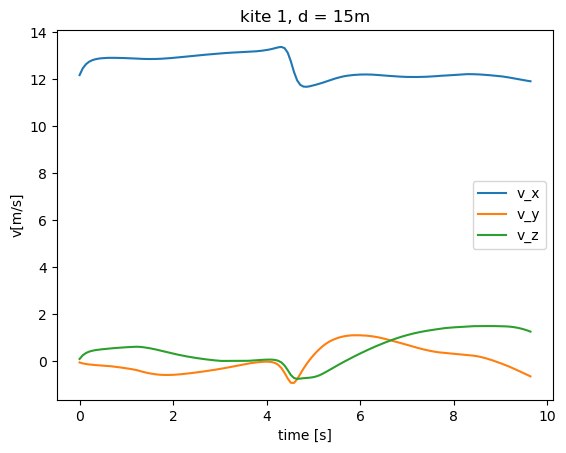

In [87]:
plt.plot(time, arr_k1[:,0], label = "v_x")
plt.plot(time, arr_k1[:,1], label = "v_y")
plt.plot(time, arr_k1[:,2], label = "v_z")
plt.legend()
plt.title("kite 1, d = 15m")
plt.xlabel("time [s]")
plt.ylabel("v[m/s]")
plt.show()